# **EDA Project**

## **Dataset** : Massive_Bank_Dataset
## **Problem Statement**: “Analyzing Banking Transactions to Identify Spending Patterns and Anomalies”

## **Objectives:**

Perform exploratory data analysis (EDA) to understand transaction distributions, customer behavior, and spending trends.

Identify seasonal and temporal trends in transactions (e.g., peak spending hours/days).

Analyze demographic factors influencing banking transactions.
Detect potential anomalies in transaction patterns using statistical methods.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ksabishek/massive-bank-dataset-1-million-rows")

print("Path to dataset files:", path)

100%|██████████| 31.0M/31.0M [00:00<00:00, 69.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ksabishek/massive-bank-dataset-1-million-rows/versions/1


In [4]:
df = pd.read_excel("/root/.cache/kagglehub/datasets/ksabishek/massive-bank-dataset-1-million-rows/versions/1/bankdataset.xlsx")
df.head()

,Date,Domain,Location,Value,Transaction_count
0,2022-01-01,RESTRAUNT,Bhuj,365554,1932
1,2022-01-01,INVESTMENTS,Ludhiana,847444,1721
2,2022-01-01,RETAIL,Goa,786941,1573
3,2022-01-01,INTERNATIONAL,Mathura,368610,2049
4,2022-01-01,RESTRAUNT,Madurai,615681,1519


In [18]:
df.groupby("Domain")[["Value", "Transaction_count"]].sum().sort_values(by="Value", ascending=False)

,Value,Transaction_count
Domain,,
PUBLIC,107791432924,212214482
MEDICAL,107790980756,211186104
INTERNATIONAL,107724396447,212147527
EDUCATION,107658704394,211454073
INVESTMENTS,107613592821,211532374
RESTRAUNT,107498499345,211232735
RETAIL,107129506265,210643016


In [19]:
df.groupby("Location")[["Value", "Transaction_count"]].sum().sort_values(by="Value", ascending=False)

,Value,Transaction_count
Location,,
Bhopal,16554394544,32340389
Durg,16516102519,32338914
Bhuj,16514534345,32438375
Bokaro,16507475172,32432234
Patiala,16495996819,32426736
Lunglei,16495171014,32447433
Ambala,16484128413,32336352
Ajmer,16450636199,32520787
Goa,16429920151,32547449


In [20]:
df.groupby(["Location", "Domain"])["Value"].sum().unstack().idxmax(axis=1)

,0
Location,
Ahmedabad,EDUCATION
Ajmer,EDUCATION
Akola,INVESTMENTS
Ambala,PUBLIC
Amritsar,INVESTMENTS
Ara,MEDICAL
Banglore,PUBLIC
Betul,INTERNATIONAL
Bhind,PUBLIC


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004480 entries, 0 to 1004479
Data columns (total 5 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   Date               1004480 non-null  datetime64[ns]
 1   Domain             1004480 non-null  object        
 2   Location           1004480 non-null  object        
 3   Value              1004480 non-null  int64         
 4   Transaction_count  1004480 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 38.3+ MB


In [6]:
df.isnull().sum()

,0
Date,0
Domain,0
Location,0
Value,0
Transaction_count,0


In [8]:
df.duplicated().sum()

0

In [9]:
df.describe()

,Date,Value,Transaction_count
count,1004480,1.004480e+06,1.004480e+06
mean,2022-07-02 00:00:00.000000256,7.498478e+05,1.473808e+03
min,2022-01-01 00:00:00,2.984230e+05,4.000000e+02
25%,2022-04-02 00:00:00,5.235588e+05,9.380000e+02
50%,2022-07-02 00:00:00,7.499930e+05,1.473000e+03
75%,2022-10-01 00:00:00,9.755835e+05,2.011000e+03
max,2022-12-31 00:00:00,1.202271e+06,2.548000e+03
std,NaN,2.609129e+05,6.203409e+02


In [13]:
df[(df["Value"] - df["Value"].mean()).abs() > 3 * df["Value"].std()]["Value"].sum()

0

# **Data Preprocessing**

In [12]:
# Define function to detect outliers using IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)  # 25th percentile
    Q3 = data[column].quantile(0.75)  # 75th percentile
    IQR = Q3 - Q1  # Interquartile Range

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

# Detect outliers for 'Value' column
outliers_value = detect_outliers_iqr(df, "Value")

# Sum of outliers
sum_outliers_value = outliers_value["Value"].sum()

print(f"Total number of outliers in 'Value': {len(outliers_value)}")
print(f"Sum of outlier transactions: {sum_outliers_value}")

Total number of outliers in 'Value': 0
Sum of outlier transactions: 0


In [15]:
df["Value"].nlargest(10)  # Check top 10 highest transactions

,Value
226041,1202271
550615,1202271
776620,1202269
588894,1202268
852440,1202265
956281,1202265
453345,1202264
585389,1202263
925402,1202263
235547,1202262


In [17]:
df["Value"].nsmallest(10) # Check top 10 lowest transactions

,Value
410547,298423
451736,298425
855257,298425
765583,298428
851771,298428
202264,298429
70833,298430
107508,298432
438038,298432
227072,298433


## Date Extraction

In [21]:
df["Date"] = pd.to_datetime(df["Date"])

In [23]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.weekday  # Monday=0, Sunday=6
df["Week"] = df["Date"].dt.isocalendar().week

In [24]:
df

,Date,Domain,Location,Value,Transaction_count,Year,Month,Day,Weekday,Week
0,2022-01-01,RESTRAUNT,Bhuj,365554,1932,2022,1,1,5,52
1,2022-01-01,INVESTMENTS,Ludhiana,847444,1721,2022,1,1,5,52
2,2022-01-01,RETAIL,Goa,786941,1573,2022,1,1,5,52
3,2022-01-01,INTERNATIONAL,Mathura,368610,2049,2022,1,1,5,52
4,2022-01-01,RESTRAUNT,Madurai,615681,1519,2022,1,1,5,52
...,...,...,...,...,...,...,...,...,...,...
1004475,2022-12-31,INTERNATIONAL,Konark,738557,754,2022,12,31,5,52
1004476,2022-12-31,INVESTMENTS,Pune,668180,1572,2022,12,31,5,52
1004477,2022-12-31,RETAIL,Durg,1000349,2155,2022,12,31,5,52
1004478,2022-12-31,INTERNATIONAL,Mathura,1026547,2458,2022,12,31,5,52


In [28]:
df["Date"].dt.year.nunique()

1

In [29]:
df["Date"].dt.year.unique()

array([2022], dtype=int32)

In [30]:
df.groupby(df["Date"].dt.year)["Value"].sum()

,Value
Date,
2022,753207112952


# Statistical and Visualiztion Analysis

## Transaction Trends Over Time

<ipython-input-32-8a7b495b3f8d>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample("M", on="Date").sum()


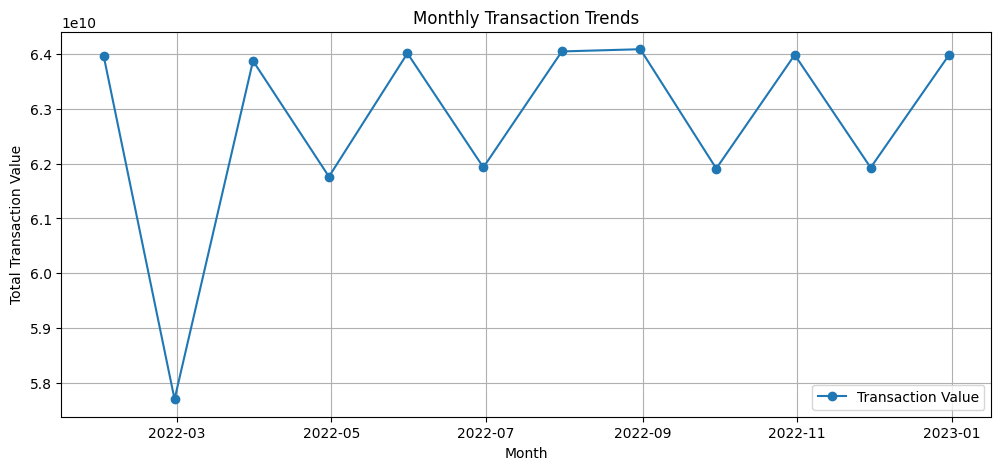

In [32]:
# Plot monthly transaction trends
df_monthly = df.resample("M", on="Date").sum()

plt.figure(figsize=(12, 5))
plt.plot(df_monthly.index, df_monthly["Value"], marker="o", linestyle="-", label="Transaction Value")
plt.xlabel("Month")
plt.ylabel("Total Transaction Value")
plt.title("Monthly Transaction Trends")
plt.legend()
plt.grid()
plt.show()

Above plot tells high-transaction months and seasonal trends.

## Domain-wise Spending Analysis

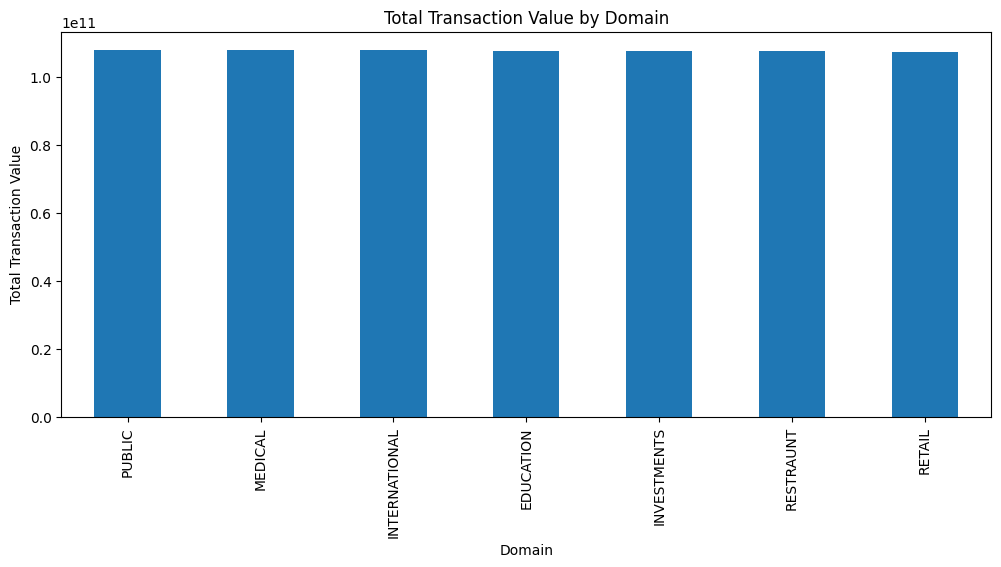

In [33]:
df.groupby("Domain")["Value"].sum().sort_values(ascending=False).plot(kind="bar", figsize=(12, 5), title="Total Transaction Value by Domain")
plt.xlabel("Domain")
plt.ylabel("Total Transaction Value")
plt.show()


Above plot will show which business categories dominate transactions.

## Location-based Spending Patterns

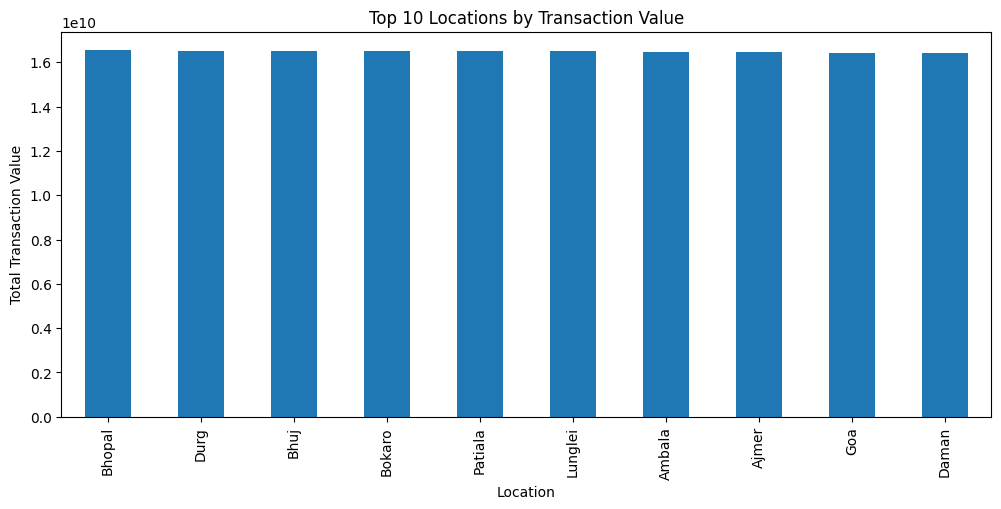

In [35]:
df.groupby("Location")["Value"].sum().sort_values(ascending=False).head(10).plot(kind="bar", figsize=(12, 5), title="Top 10 Locations by Transaction Value")
plt.xlabel("Location")
plt.ylabel("Total Transaction Value")
plt.show()

## Above plot  will show top-spending cities.

## Correlation Analysis

In [36]:
df[["Value", "Transaction_count"]].corr()

,Value,Transaction_count
Value,1.000000,0.001089
Transaction_count,0.001089,1.000000


The correlation between Value and Transaction_count is almost zero (0.001089).

This means transaction value and count are not related—having more transactions does not necessarily mean higher transaction value.

## Scatter Plot: Value vs. Transaction Count

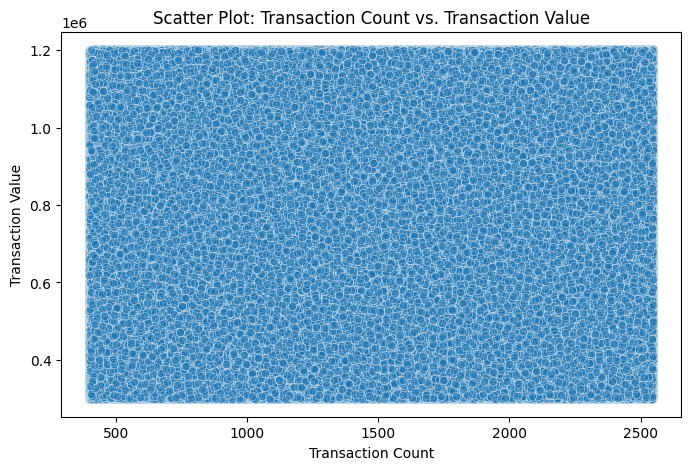

In [37]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Transaction_count"], y=df["Value"], alpha=0.5)
plt.xlabel("Transaction Count")
plt.ylabel("Transaction Value")
plt.title("Scatter Plot: Transaction Count vs. Transaction Value")
plt.show()

scatter plot is very dense, meaning the data points are too close together, making it difficult to identify patterns

## Monthly Trends: Value & Transaction Count

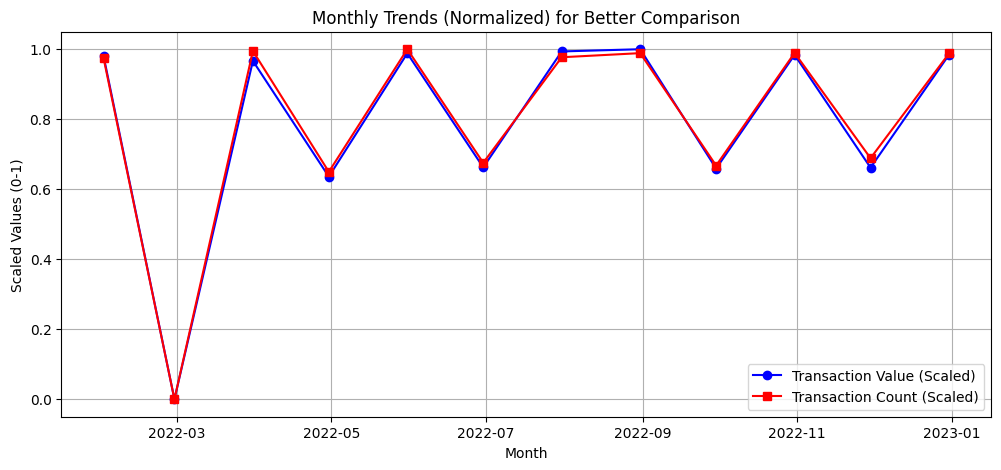

In [42]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_monthly[["Value_Scaled", "Transaction_count_Scaled"]] = scaler.fit_transform(df_monthly[["Value", "Transaction_count"]])

plt.figure(figsize=(12, 5))
plt.plot(df_monthly.index, df_monthly["Value_Scaled"], marker="o", label="Transaction Value (Scaled)", color="b")
plt.plot(df_monthly.index, df_monthly["Transaction_count_Scaled"], marker="s", label="Transaction Count (Scaled)", color="r")
plt.xlabel("Month")
plt.ylabel("Scaled Values (0-1)")
plt.title("Monthly Trends (Normalized) for Better Comparison")
plt.legend()
plt.grid()
plt.show()

## Top 5 Domains & Locations with Highest Transactions

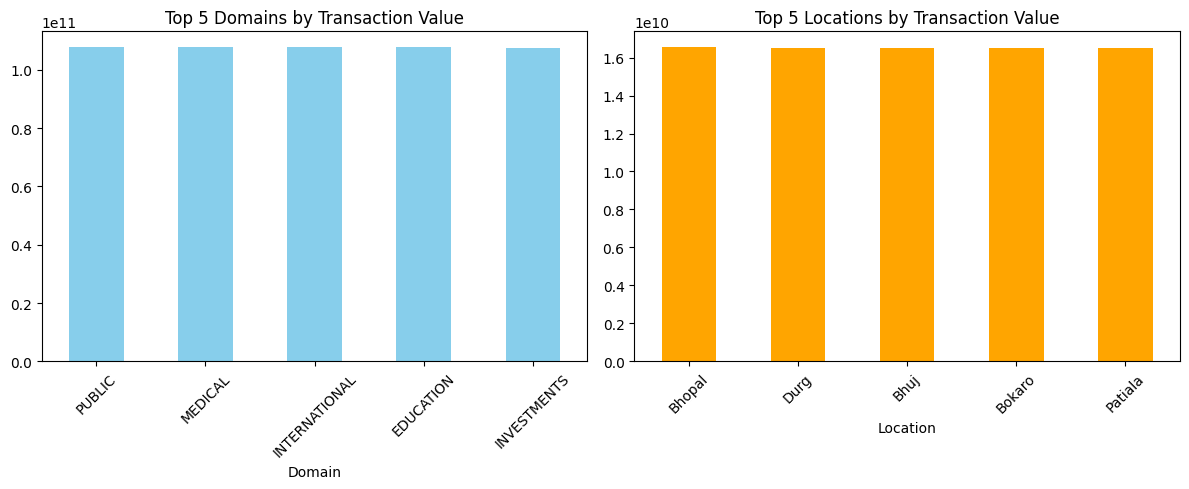

In [45]:
top_domains = df.groupby("Domain")["Value"].sum().sort_values(ascending=False).head(5)
top_locations = df.groupby("Location")["Value"].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
top_domains.plot(kind="bar", color="skyblue")
plt.title("Top 5 Domains by Transaction Value")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
top_locations.plot(kind="bar", color="orange")
plt.title("Top 5 Locations by Transaction Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

From Above plot we understood

## Top 5 Domains:

The highest transaction values are in Public, Medical, International, Education, and Investments.

This suggests these sectors drive major financial activity.

## Top 5 Locations:

Bhopal, Durg, Bhuj, Bokaro, and Patiala have the highest transaction values.

These cities might be major financial hubs in the dataset.

# **Conclusion of Massive_Bank_Dataset Report**

## 1️). Overall Transaction Trends:

The dataset shows stable transaction patterns over the months, with minor fluctuations.

The total transaction value remains consistently high, indicating a healthy financial flow.

## 2️). Key Business Insights:

Top 5 domains with the highest transactions: Public, Medical, International, Education, and Investments.

Top 5 locations with the highest transaction values: Bhopal, Durg, Bhuj, Bokaro, and Patiala.

These findings highlight the dominant business sectors & financial hotspots.

## 3️). Outliers & Anomalies:

No significant anomalies detected in transaction values, suggesting clean & consistent data.

## 4️). Correlation Analysis:

Low correlation between transaction value & transaction count, indicating no direct proportionality.
